In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, RocCurveDisplay, recall_score

In [ ]:
df = pd.read_csv("booking.csv")
df.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


In [ ]:
df.shape

(36285, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  specia

In [ ]:
df.describe()

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,special requests
count,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000
mean,1.844839,0.105360,0.810693,2.204602,0.030977,85.239851,0.025630,0.023343,0.153369,103.421636,0.619733
std,0.518813,0.402704,0.870590,1.410946,0.173258,85.938796,0.158032,0.368281,1.753931,35.086469,0.786262
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,1.000000,13.000000,58.000000,540.000000,5.000000


In [ ]:
df.columns

Index(['Booking_ID', 'number of adults', 'number of children',
       'number of weekend nights', 'number of week nights', 'type of meal',
       'car parking space', 'room type', 'lead time', 'market segment type',
       'repeated', 'P-C', 'P-not-C', 'average price', 'special requests',
       'date of reservation', 'booking status'],
      dtype='object')

In [ ]:
df.drop('Booking_ID', axis=1, inplace=True)

In [ ]:
X = df.drop('booking status', axis=1)
Y = df['booking status']

In [ ]:
df.isnull().sum()

,0
number of adults,0
number of children,0
number of weekend nights,0
number of week nights,0
type of meal,0
car parking space,0
room type,0
lead time,0
market segment type,0
repeated,0


In [ ]:
print(X.dtypes)

number of adults              int64
number of children            int64
number of weekend nights      int64
number of week nights         int64
type of meal                 object
car parking space             int64
room type                    object
lead time                     int64
market segment type          object
repeated                      int64
P-C                           int64
P-not-C                       int64
average price               float64
special requests              int64
date of reservation          object
dtype: object


In [ ]:
le = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col])

In [ ]:
X['date of reservation'] = pd.to_datetime(X['date of reservation'])

X['reservation_year'] = X['date of reservation'].dt.year
X['reservation_month'] = X['date of reservation'].dt.month
X['reservation_day'] = X['date of reservation'].dt.day

X.drop('date of reservation', axis=1, inplace=True)

In [ ]:
print(Y.unique())

['Not_Canceled' 'Canceled']


In [ ]:
Y = Y.map({'Canceled':1, 'Not_Canceled':0})

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

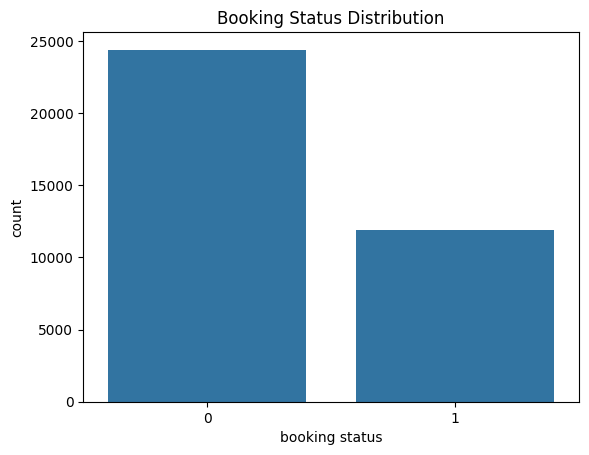

In [ ]:
sns.countplot(x=Y)
plt.title("Booking Status Distribution")
plt.show()

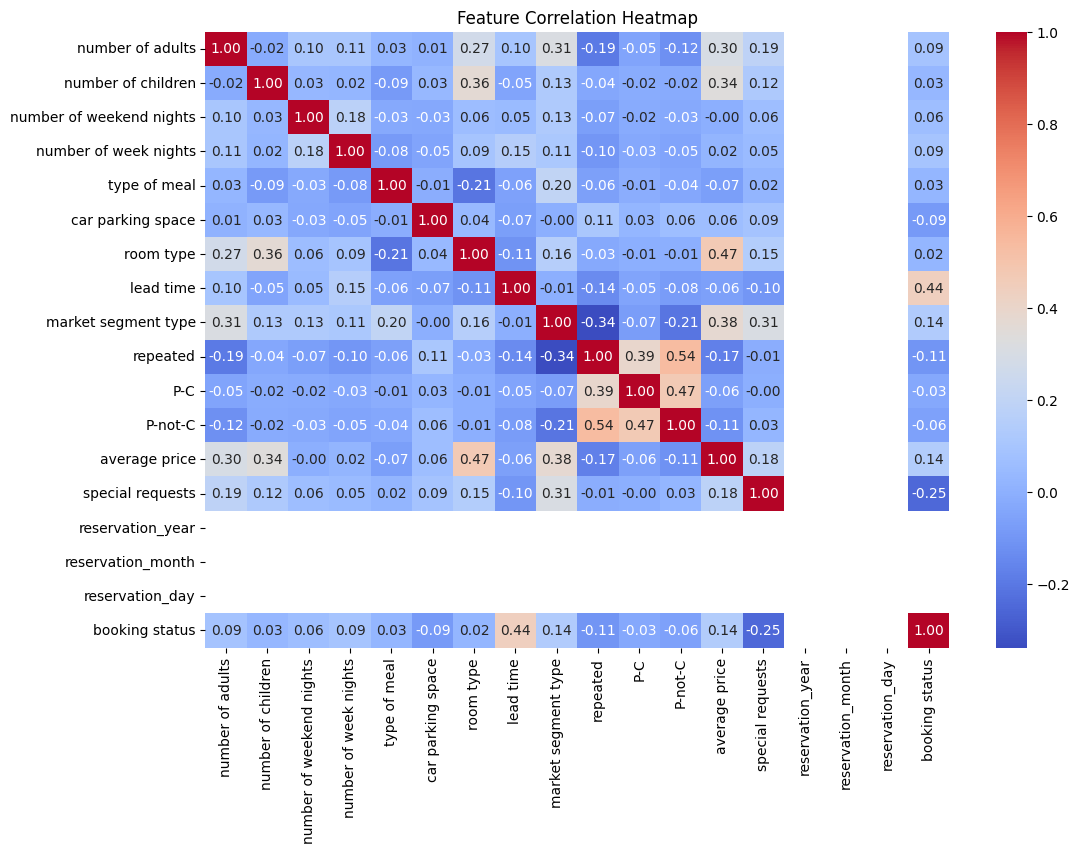

In [ ]:
temp_df = X.copy()
temp_df['booking status'] = Y
plt.figure(figsize=(12,8))
sns.heatmap(temp_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
dummy=DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, Y_train)

Y_dummy=dummy.predict(X_test)

print("Dummy Accuracy:", accuracy_score(Y_test, Y_dummy))

Dummy Accuracy: 0.669009232465206


In [ ]:
lr_params = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    lr_params,
    cv=3,
    scoring='accuracy'
)

lr_grid.fit(X_train, Y_train)

print("Best LR Params:", lr_grid.best_params_)

Best LR Params: {'C': 10, 'solver': 'liblinear'}


In [ ]:
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(),
    rf_params,
    cv=3,
    scoring='accuracy'
)

rf_grid.fit(X_train, Y_train)

print("Best RF Params:", rf_grid.best_params_)

Best RF Params: {'max_depth': 10, 'n_estimators': 50}


In [ ]:
gb_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(),
    gb_params,
    cv=3,
    scoring='accuracy'
)

gb_grid.fit(X_train, Y_train)

print("Best GB Params:", gb_grid.best_params_)

Best GB Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


In [ ]:
lr_best = lr_grid.best_estimator_
rf_best = rf_grid.best_estimator_
gb_best = gb_grid.best_estimator_

In [ ]:
y_pred_lr = lr_best.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(Y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(Y_test, y_pred_lr))
print("Classification Report:\n", classification_report(Y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.8033622709108447
Confusion Matrix:
 [[4368  487]
 [ 940 1462]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.90      0.86      4855
           1       0.75      0.61      0.67      2402

    accuracy                           0.80      7257
   macro avg       0.79      0.75      0.77      7257
weighted avg       0.80      0.80      0.80      7257



In [ ]:
y_pred_rf = rf_best.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(Y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(Y_test, y_pred_rf))
print("Classification Report:\n", classification_report(Y_test, y_pred_rf))

Random Forest
Accuracy: 0.8617886178861789
Confusion Matrix:
 [[4570  285]
 [ 718 1684]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.94      0.90      4855
           1       0.86      0.70      0.77      2402

    accuracy                           0.86      7257
   macro avg       0.86      0.82      0.84      7257
weighted avg       0.86      0.86      0.86      7257



In [ ]:
y_pred_gb = gb_best.predict(X_test)

print("Gradient Boosting")
print("Accuracy:", accuracy_score(Y_test, y_pred_gb))
print("Confusion Matrix:\n", confusion_matrix(Y_test, y_pred_gb))
print("Classification Report:\n", classification_report(Y_test, y_pred_gb))

Gradient Boosting
Accuracy: 0.8482844150475403
Confusion Matrix:
 [[4526  329]
 [ 772 1630]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.93      0.89      4855
           1       0.83      0.68      0.75      2402

    accuracy                           0.85      7257
   macro avg       0.84      0.81      0.82      7257
weighted avg       0.85      0.85      0.84      7257



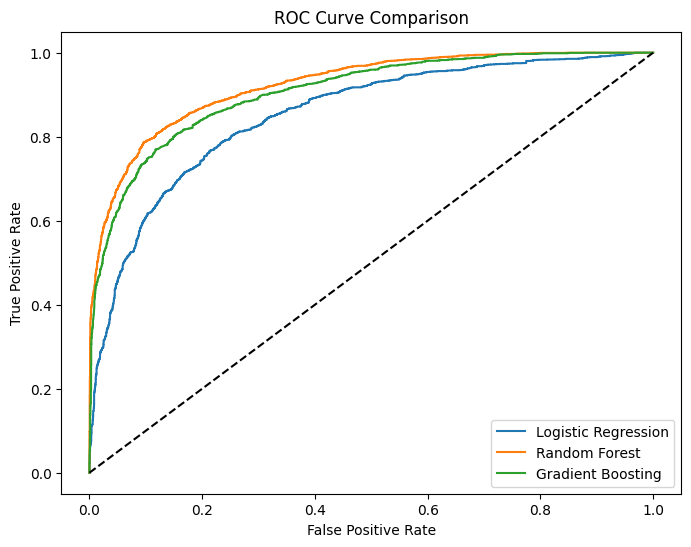

In [ ]:
plt.figure(figsize=(8,6))
#Logistic Regression
y_prob_lr = lr_best.predict_proba(X_test)[:,1]
fpr_lr, tpr_lr, _ = roc_curve(Y_test, y_prob_lr)
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
#Random Forest
y_prob_rf = rf_best.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(Y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
#Gradident Boosting
y_prob_gb = gb_best.predict_proba(X_test)[:,1]
fpr_gb, tpr_gb, _ = roc_curve(Y_test, y_prob_gb)
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting")
#Baseline
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)
auc_gb = auc(fpr_gb, tpr_gb)

print("AUC LR:", auc_lr)
print("AUC RF:", auc_rf)
print("AUC GB:", auc_gb)

AUC LR: 0.8517972921638421
AUC RF: 0.9229415754636326
AUC GB: 0.9060969617663277
